In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('/content/NYC.csv')

In [8]:
print("Shape:", df.shape)

print("\nData Info:")
df.info()

Shape: (1458644, 11)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [12]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.day_name()
df['month'] = df['pickup_datetime'].dt.month

In [13]:
df['trip_duration_minutes'] = df['trip_duration'] / 60

In [16]:
print("\nBefore filtering:", len(df))

df = df[(df['trip_duration_minutes'] >= 1) & (df['trip_duration_minutes'] <= 120)]

print("After filtering:", len(df))


Before filtering: 1447796
After filtering: 1447796


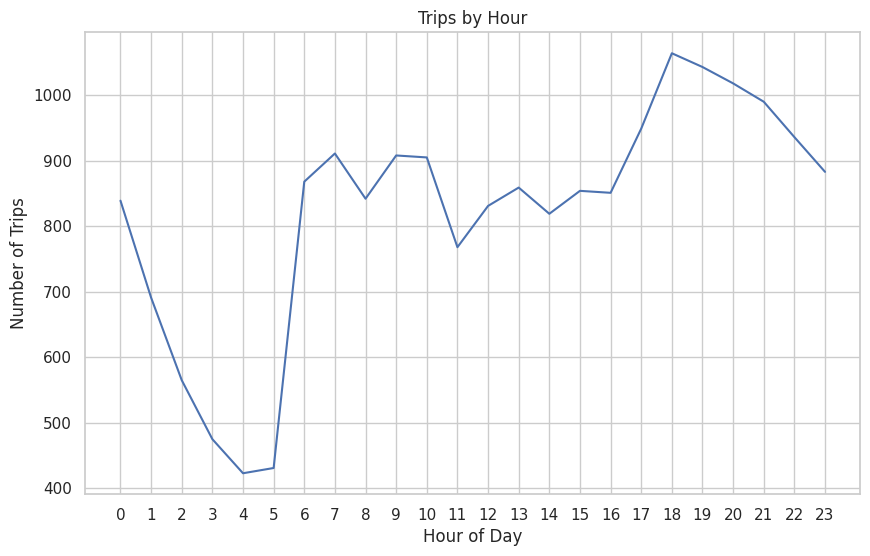

In [25]:
hourly_demand = df.groupby('hour').size().sort_index()

plt.plot(hourly_demand.index, hourly_demand.values)
plt.title('Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.show()

In [27]:
peak_hour = hourly_demand.idxmax()
off_peak_hour = hourly_demand.idxmin()

print(f"\nPeak Hour: {peak_hour} ")
print(f"Off-Peak Hour: {off_peak_hour} ")


Peak Hour: 18 
Off-Peak Hour: 4 


/tmp/ipykernel_11149/3077669197.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_demand = df.groupby('weekday').size()


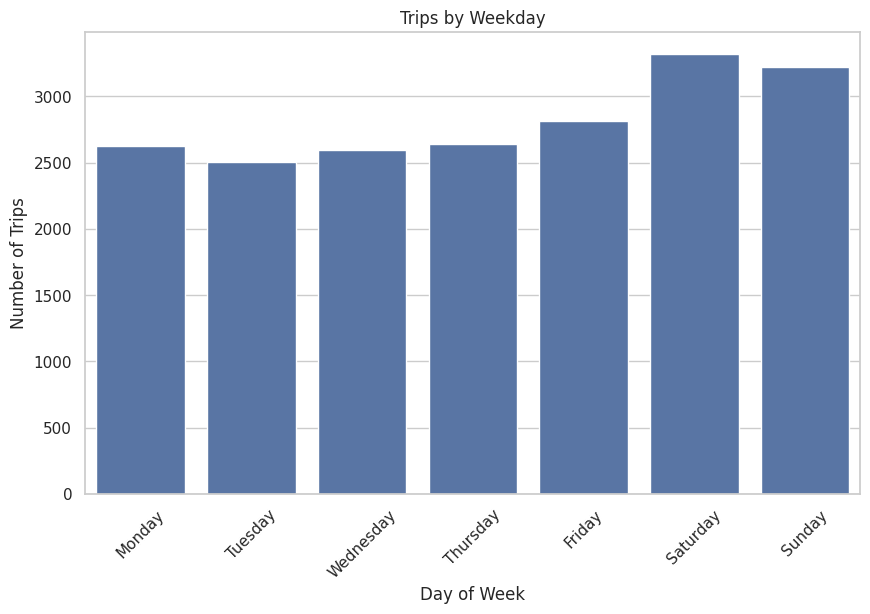

In [28]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_order, ordered=True)
weekly_demand = df.groupby('weekday').size()

sns.barplot(x=weekly_demand.index, y=weekly_demand.values)
plt.title('Trips by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

In [32]:
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

weekend_analysis = df.groupby('is_weekend').size()

print("\nWeekday vs Weekend Trips:\n")
print(weekend_analysis)


Weekday vs Weekend Trips:

is_weekend
False    13179
True      6544
dtype: int64


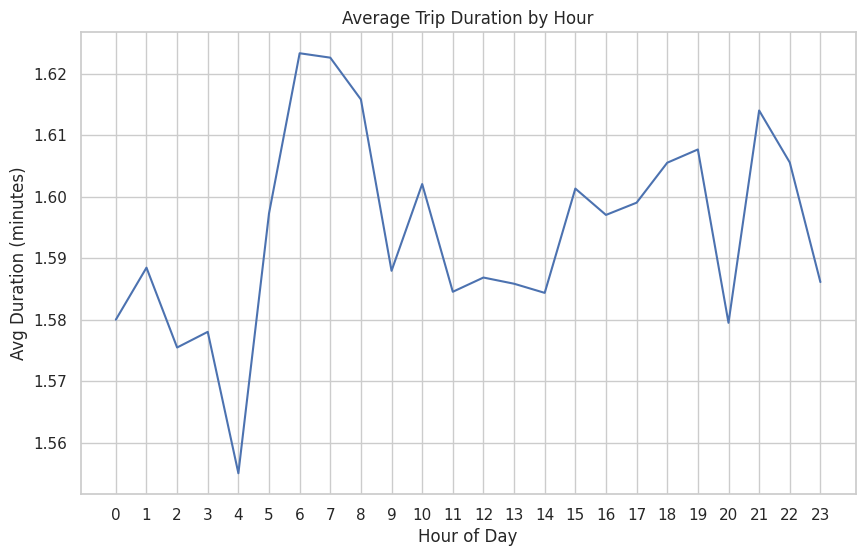

In [33]:
avg_duration_hour = df.groupby('hour')['trip_duration_minutes'].mean().sort_index()

plt.plot(avg_duration_hour.index, avg_duration_hour.values)
plt.title('Average Trip Duration by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Duration (minutes)')
plt.xticks(range(0, 24))
plt.show()

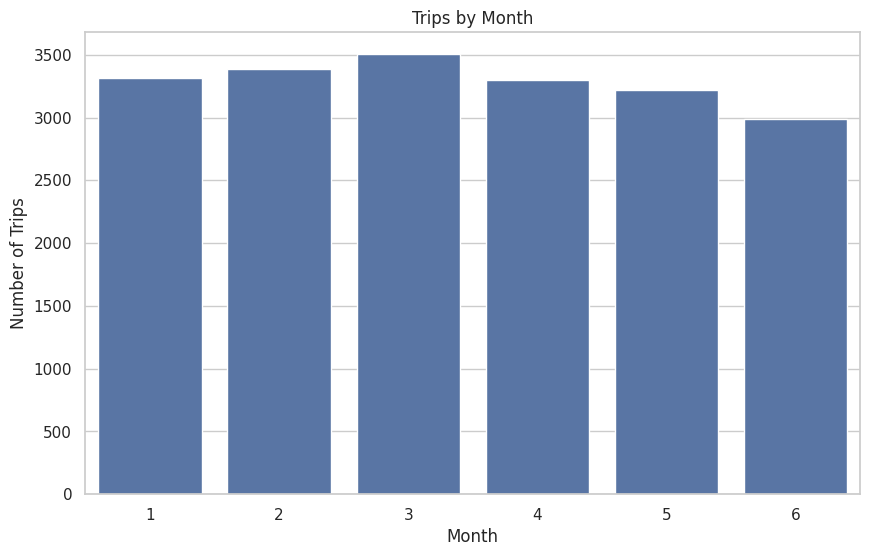

In [34]:
monthly_trips = df.groupby('month').size().sort_index()

sns.barplot(x=monthly_trips.index, y=monthly_trips.values)
plt.title('Trips by Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.show()

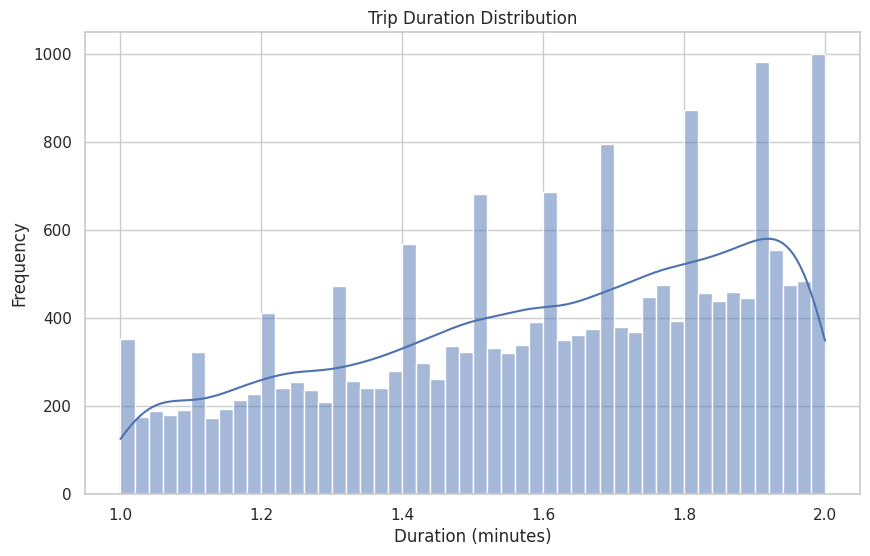

In [35]:
sns.histplot(df['trip_duration_minutes'], bins=50, kde=True)
plt.title('Trip Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_11149/612160595.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(['hour', 'weekday']).size().unstack()


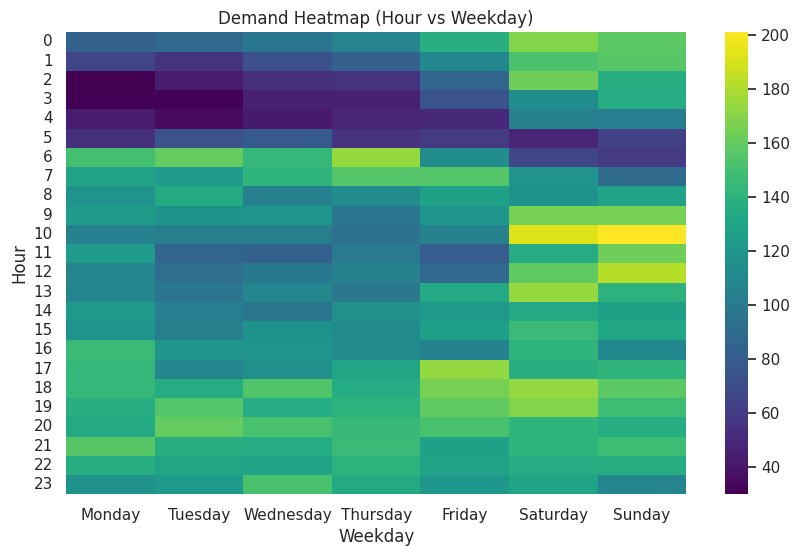

In [38]:
heatmap_data = df.groupby(['hour', 'weekday']).size().unstack()
heatmap_data = heatmap_data.fillna(0)
heatmap_data = heatmap_data[weekday_order]
heatmap_data = heatmap_data.sort_index()

sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Demand Heatmap (Hour vs Weekday)')
plt.xlabel('Weekday')
plt.ylabel('Hour')
plt.show()


Vendor Comparison:
               mean  count
vendor_id                 
1          1.593875   9325
2          1.598352  10398


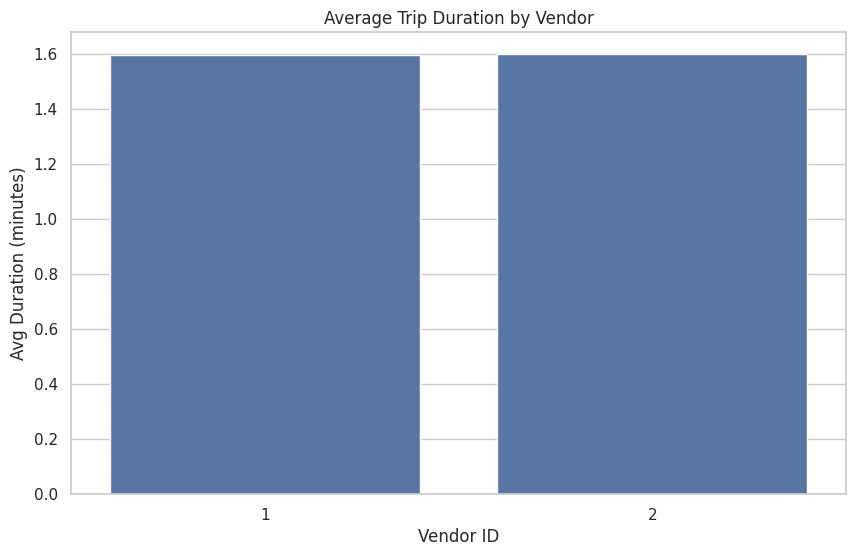

In [39]:
vendor_comparison = df.groupby('vendor_id')['trip_duration_minutes'].agg(['mean', 'count'])

print("\nVendor Comparison:")
print(vendor_comparison)

sns.barplot(x=vendor_comparison.index.astype(str), y=vendor_comparison['mean'])
plt.title('Average Trip Duration by Vendor')
plt.xlabel('Vendor ID')
plt.ylabel('Avg Duration (minutes)')
plt.show()